# Импорты и зависимости

In [1]:
!uv pip install depth-anything-3

Using Python 3.10.19 environment at: /home/stepan/.venv
Audited 1 package in 65ms


In [ ]:
import os
from itertools import chain
from pathlib import Path

import numpy as np
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset

from depth_anything_3.api import DepthAnything3

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print(f"Using device: {device}")

Using device: cuda


# Подготовка данных

## Вычисление и запись в файлы карт глубины

In [ ]:
model = DepthAnything3.from_pretrained(
    "depth-anything/da3-base", torch_dtype=torch.float16
)
model = model.to(device)
model.eval()

In [ ]:
def preprocess_images(image_paths):
    prediction = model.inference(
        image=image_paths,
        process_res=504,
        process_res_method="upper_bound_resize",
        export_dir=None,
        export_format="glb",
    )
    return (prediction.processed_images, prediction.depth)


def prepare_data(path_to_images: str):
    for data_kind in filter(
        lambda p: os.path.isdir(path_to_images + "/" + p), os.listdir(path_to_images)
    ):
        path_data_kind = f"{path_to_images}/{data_kind}"
        for data_class in filter(
            lambda p: os.path.isdir(path_data_kind + "/" + p),
            os.listdir(path_data_kind),
        ):
            path_data_class = f"{path_to_images}/{data_kind}/{data_class}"

            image_paths = [
                f"{path_data_class}/{filename}"
                for filename in os.listdir(path_data_class)
                if filename.find("120tore") == -1
            ]

            for i in range(1, len(image_paths), 1):
                l, r = i - 1, min(len(image_paths), i)
                image_paths_part = image_paths[l:r]
                processed_images, depths = preprocess_images(image_paths_part)

                os.makedirs(
                    path_data_class.replace("data", "data_prepared"), exist_ok=True
                )
                for processed_image, depth, image_path in zip(
                    processed_images, depths, image_paths_part
                ):
                    img_processed = Image.fromarray(processed_image.astype(np.uint8))
                    img_depthed = Image.fromarray(depth.astype(np.uint8))

                    img_processed.save(image_path.replace("data", "data_prepared"))
                    img_depthed.save(
                        image_path.replace("data", "data_prepared").replace(
                            ".jpg", "depth.jpg"
                        )
                    )

In [ ]:
prepare_data("data")

## Упаковка в dalaloader'ы

In [34]:
from torchvision import transforms


class CustomDataset(Dataset):
    def __init__(self, path_to_images, is_depth):
        self.kinds = os.listdir(path_to_images)[:-1]
        path_to_images = Path(path_to_images)

        def paths_filter(path):
            return is_depth if path.find("depth") != -1 else (not is_depth)

        objs_grouped = [
            [
                (kind, str(path_to_images / Path(kind) / Path(file_path)))
                for file_path in os.listdir(path_to_images / Path(kind))
                if paths_filter(file_path)
            ]
            for kind in self.kinds
        ]
        self.objs = list(chain.from_iterable(objs_grouped))
        self.transform = transforms.Compose(
            [
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
            ]
        )

    def __getitem__(self, idx):
        label, file_path = self.objs[idx]

        label = self.kinds.index(label)
        image = Image.open(file_path)
        image = self.transform(image)

        return image, label

    def __len__(self):
        return len(self.objs)

In [35]:
depth_dataset_train = CustomDataset("data_prepared/train", True)
usual_dataset_train = CustomDataset("data_prepared/train", False)

depth_dataset_val = CustomDataset("data_prepared/val", True)
usual_dataset_val = CustomDataset("data_prepared/val", False)

In [36]:
depth_dataloader_train = DataLoader(depth_dataset_train, batch_size=32, shuffle=True)
usual_dataloader_train = DataLoader(usual_dataset_train, batch_size=32, shuffle=True)

depth_dataloader_val = DataLoader(depth_dataset_val, batch_size=32, shuffle=True)
usual_dataloader_val = DataLoader(usual_dataset_val, batch_size=32, shuffle=True)

## Проверка данных

In [122]:
from matplotlib import pyplot as plt
from depth_anything_3.utils.visualize import visualize_depth


def show_by_index(idx):
    fig, axes = plt.subplots(1, 2, figsize=(6, 6))

    rgb_image = Image.fromarray(
        (usual_dataset_train[idx][0].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    )
    depth_image = visualize_depth(
        depth_dataset_train[idx][0][0].numpy(), cmap="Spectral"
    )

    axes[0].imshow(rgb_image)
    axes[0].set_title("RGB Image")
    axes[0].axis("off")

    axes[1].imshow(depth_image)
    axes[1].set_title("Depth Map")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

### Здоровый лист

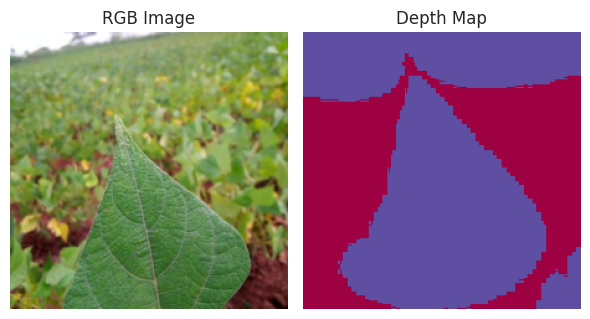

In [123]:
show_by_index(0)

### Нездоровый лист

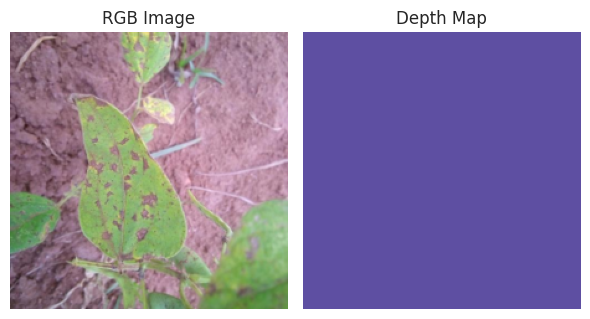

In [128]:
show_by_index(-1)

## Обучение моделей классификации

In [38]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [105]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm import tqdm


def train_epoch(model, dataloader, criterion, optimizer, device, is_depth):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in dataloader:
        if is_depth:
            images, labels = (
                images.repeat(1, 3, 1, 1).to(device),
                labels.to(device),
            )
        else:
            images, labels = (
                images.to(device),
                labels.to(device),
            )

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # подсчет epoch_loss, epoch_acc, epoch_f1
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_f1


def validate(model, dataloader, criterion, device, is_depth):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation"):
            if is_depth:
                images, labels = (
                    images.repeat(1, 3, 1, 1).to(device),
                    labels.to(device),
                )
            else:
                images, labels = (
                    images.to(device),
                    labels.to(device),
                )

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # подсчет loss, acc, f1, precision, recall
    loss = running_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)

    return loss, acc, f1, precision, recall

In [106]:
from torchvision import models


def run_training(num_epochs=10, is_depth=True):
    model = models.resnet18()
    model.load_state_dict(torch.load("resnet_initial_weights.pth"))
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 2)
    model = model.to(device)

    train_losses = []
    train_accs = []
    train_f1s = []

    dataloader = depth_dataloader_train if is_depth else usual_dataloader_train

    model.train()
    for epoch in range(num_epochs):
        if epoch % 20 == 0:
            print(f"\nEpoch {epoch + 1}/{num_epochs}")
            print("-" * 50)

        train_loss, train_acc, train_f1 = train_epoch(
            model, dataloader, criterion, optimizer, device, is_depth
        )
        scheduler.step()

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        train_f1s.append(train_f1)

        if epoch % 20 == 0:
            print(
                f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}"
            )

    print("\nTraining completed!")

    return model, train_losses, train_accs, train_f1s


In [107]:
depth_model, depth_train_losses, depth_train_accs, depth_train_f1s = run_training(
    num_epochs=100, is_depth=True
)


Epoch 1/100
--------------------------------------------------
Train Loss: 22.5039, Acc: 0.5073, F1: 0.5652

Epoch 21/100
--------------------------------------------------
Train Loss: 22.4610, Acc: 0.5088, F1: 0.5636

Epoch 41/100
--------------------------------------------------
Train Loss: 22.4312, Acc: 0.5161, F1: 0.5740

Epoch 61/100
--------------------------------------------------
Train Loss: 22.4905, Acc: 0.4868, F1: 0.5540

Epoch 81/100
--------------------------------------------------
Train Loss: 22.4784, Acc: 0.5044, F1: 0.5603

Training completed!


In [108]:
usual_model, usual_train_losses, usual_train_accs, usual_train_f1s = run_training(
    num_epochs=100, is_depth=False
)


Epoch 1/100
--------------------------------------------------
Train Loss: 22.3031, Acc: 0.5424, F1: 0.6803

Epoch 21/100
--------------------------------------------------
Train Loss: 22.4126, Acc: 0.5322, F1: 0.6735

Epoch 41/100
--------------------------------------------------
Train Loss: 22.3252, Acc: 0.5336, F1: 0.6755

Epoch 61/100
--------------------------------------------------
Train Loss: 22.4075, Acc: 0.5351, F1: 0.6755

Epoch 81/100
--------------------------------------------------
Train Loss: 22.3225, Acc: 0.5439, F1: 0.6797

Training completed!


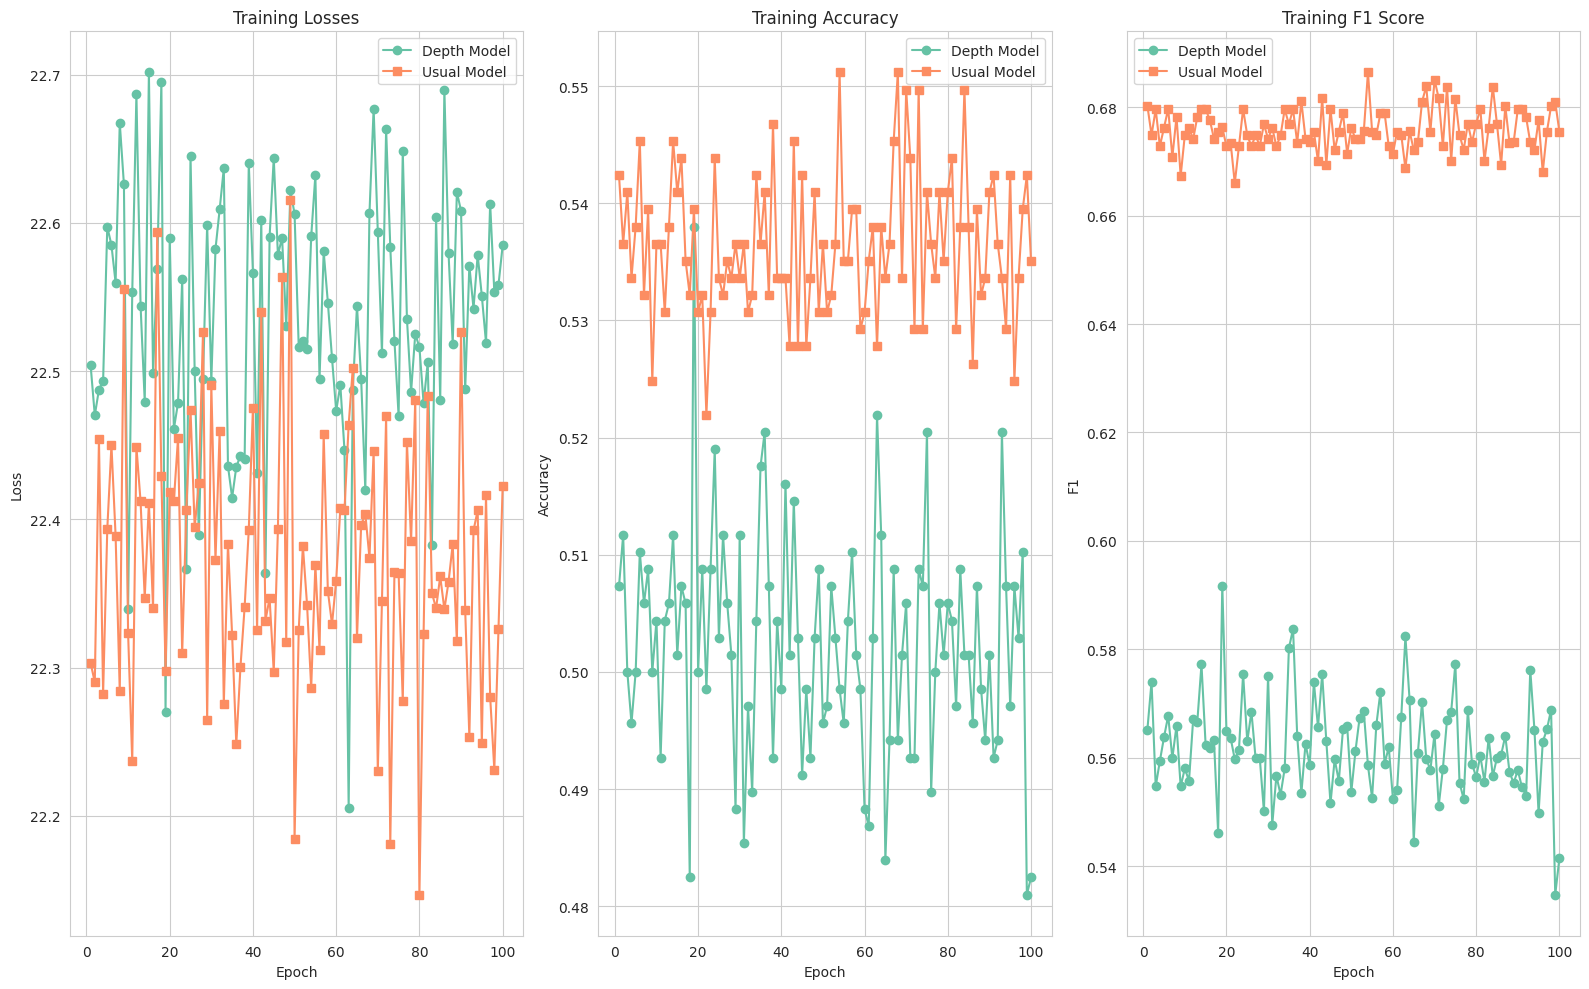

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

epochs = np.arange(1, len(depth_train_losses) + 1)

sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (15, 5)

fig, axes = plt.subplots(1, 3, figsize=(16, 10))

# 1. График потерь (Losses)
axes[0].plot(epochs, depth_train_losses, marker="o", label="Depth Model")
axes[0].plot(epochs, usual_train_losses, marker="s", label="Usual Model")
axes[0].set_title("Training Losses")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# 2. График точности (Accuracy)
axes[1].plot(epochs, depth_train_accs, marker="o", label="Depth Model")
axes[1].plot(epochs, usual_train_accs, marker="s", label="Usual Model")
axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

# 3. График F1-меры
axes[2].plot(epochs, depth_train_f1s, marker="o", label="Depth Model")
axes[2].plot(epochs, usual_train_f1s, marker="s", label="Usual Model")
axes[2].set_title("Training F1 Score")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("F1")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


# Сравнение на валидационных данных

In [118]:
import pandas as pd

depth_loss, depth_acc, depth_f1, depth_precision, depth_recall = validate(
    depth_model, depth_dataloader_val, criterion, device, True
)
usual_loss, usual_acc, usual_f1, usual_precision, usual_recall = validate(
    usual_model, usual_dataloader_val, criterion, device, False
)

# Данные из вашего кода
depth_metrics = {
    "model": "Depth",
    "loss": depth_loss,
    "accuracy": depth_acc,
    "f1": depth_f1,
    "precision": depth_precision,
    "recall": depth_recall,
}

usual_metrics = {
    "model": "Usual",
    "loss": usual_loss,
    "accuracy": usual_acc,
    "f1": usual_f1,
    "precision": usual_precision,
    "recall": usual_recall,
}

df_compare = pd.DataFrame([depth_metrics, usual_metrics])
df_compare.set_index("model", inplace=True)
df_compare

Validation: 100%|██████████| 3/3 [00:00<00:00,  7.51it/s]


,loss,accuracy,f1,precision,recall
model,,,,,
Depth,20.969673,0.488372,0.541667,0.490566,0.604651
Usual,22.121584,0.511628,0.661290,0.506173,0.953488


# Выводы

Модель, обученная на картах глубины проиграла обычной по всем параметрам. Возможные причины:
1. Здоровый лист не сильно отличается от нездорового по картам глубины, хоть и на последнем видны четкие пятна. Это говорит о критической важности наличия отличий между объектами разных классов на пространственном уровне, а также устойчивости модели к такого рода 
2. Модель `depth-anything/da3-base` неточно вычислила карты глубин (см изображения из раздела "Проверка"). Возможности загрузить не-base модель нет, так как они не помещаются в видеопамять

В связи с плачевными умозаключениями выше использовать модели `depth-anything` без наличия хотя бы 8 Гб видеопамяти (версия large-giant весит 6 Гб) не вижу никакого смысла